In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import RobustScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

import joblib, os

In [ ]:
payment_fraud_df = pd.read_csv('./online_payments_fraud_detection_dataset.csv')

payment_fraud_df

**<h1>Exploratory Data Analysis</h1>**

In [ ]:
print(f"Shape of the dataset {payment_fraud_df.shape}")
print(f"The dataset has {payment_fraud_df.shape[0]} rows and {payment_fraud_df.shape[1]} columns")

Shape of the dataset (6362620, 11)
The dataset has 6362620 rows and 11 columns


In [ ]:
# All the feature details of the dataset

payment_fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [ ]:
# total features (initially) 
features_names = payment_fraud_df.columns.tolist()
print(f"There are total {len(features_names)} features")
print(features_names)

There are total 11 features
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [ ]:
numerical_features_data = payment_fraud_df.select_dtypes(include='number')
numerical_features_name = numerical_features_data.columns.tolist()

print(f"There are total {len(numerical_features_name)} numerical features")
print(numerical_features_name)

There are total 8 numerical features
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [ ]:
categorical_features_data = payment_fraud_df.select_dtypes(include='object')
categorical_features_name_list = categorical_features_data.columns.tolist()

print(f"There are total {len(categorical_features_name_list)} categorical features")
print(categorical_features_name_list)

There are total 3 categorical features
['type', 'nameOrig', 'nameDest']


/tmp/ipykernel_17435/2219234655.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_data = payment_fraud_df.select_dtypes(include='object')


In [ ]:
categorical_features_data.describe().T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


In [ ]:
numerical_features_data.var()

step              2.025839e+04
amount            3.646448e+11
oldbalanceOrg     8.341946e+12
newbalanceOrig    8.550060e+12
oldbalanceDest    1.155443e+13
newbalanceDest    1.349922e+13
isFraud           1.289154e-03
isFlaggedFraud    2.514681e-06
dtype: float64

In [ ]:
numerical_features_data.skew()

step                0.375177
amount             30.993949
oldbalanceOrg       5.249136
newbalanceOrig      5.176884
oldbalanceDest     19.921758
newbalanceDest     19.352302
isFraud            27.779538
isFlaggedFraud    630.603629
dtype: float64

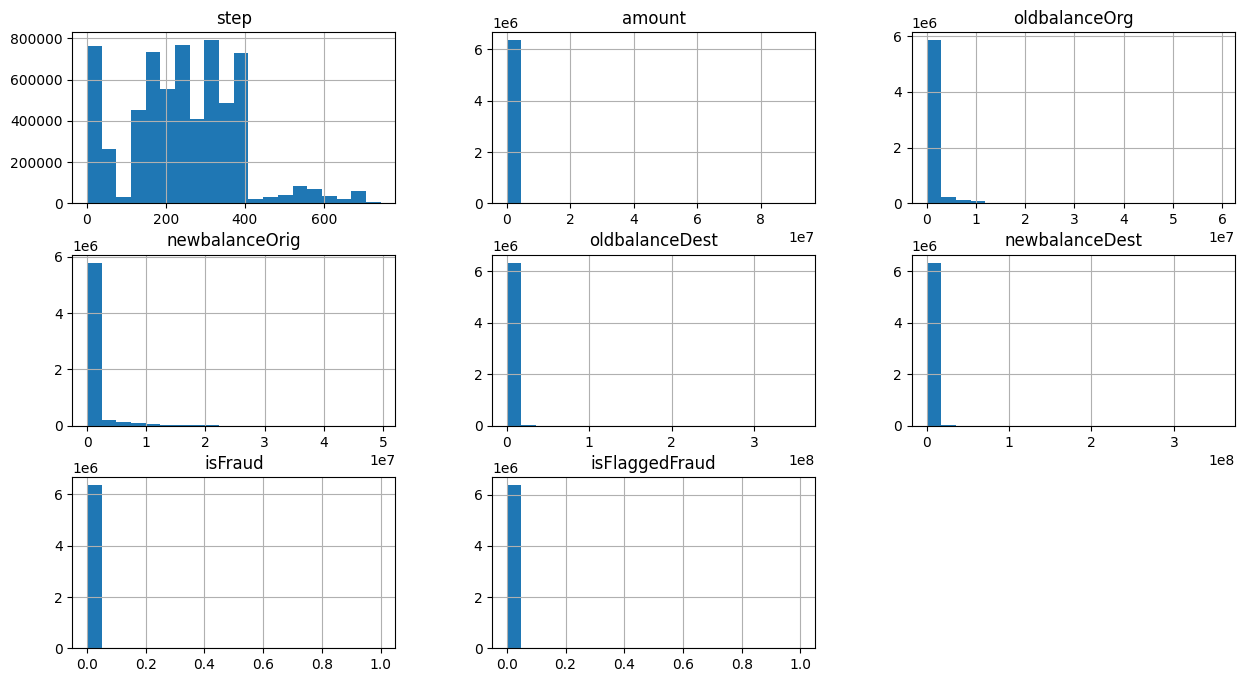

In [ ]:
numerical_features_data.hist(figsize=(15,8),bins=20)
plt.show()

**<h1>Data preprocessing</h1>**

In [ ]:
initial_null_values = payment_fraud_df.isnull().sum()
initial_null_values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

As There are no null values in the dataset, No imputation or row/column removal is needed for missing data

In [ ]:
print(f"Only {payment_fraud_df['isFlaggedFraud'].sum()} payments are flagged as fraud out of {payment_fraud_df.shape[0]} transactions!\nSo this feature (isFlaggedFraud) may leak target")

print(f'"nameOrig" and "nameDest" are also not useful for modeling, and these may introduce noise')

Only 16 payments are flagged as fraud out of 6362620 transactions!
So this feature (isFlaggedFraud) may leak target
"nameOrig" and "nameDest" are also not useful for modeling, and these may introduce noise


In [ ]:
# deleting less relevant columns

payment_fraud_df = payment_fraud_df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

In [ ]:
# current state of the dataframe
payment_fraud_df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1


In [ ]:
# after deleting (Categorical data)

categorical_features_data = payment_fraud_df.select_dtypes(include='object')
categorical_features_name_list = categorical_features_data.columns.tolist()

print(f"There are total {len(categorical_features_name_list)} categorical features")
print(categorical_features_name_list)

There are total 1 categorical features
['type']


/tmp/ipykernel_17435/1659553943.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_data = payment_fraud_df.select_dtypes(include='object')


In [ ]:
unique_categorical_data_count = categorical_features_data.nunique()
print(unique_categorical_data_count)

type    5
dtype: int64


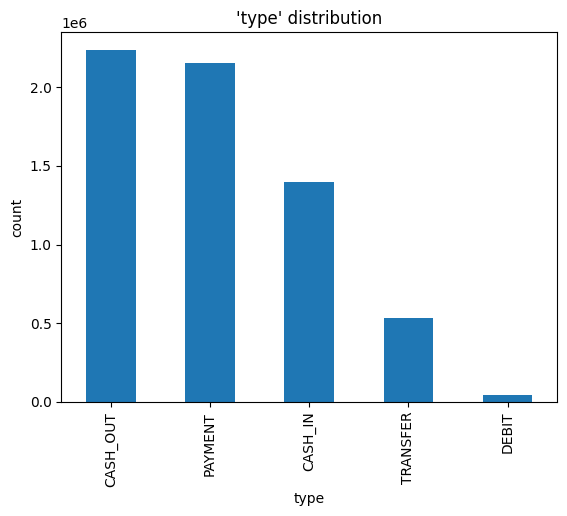

In [ ]:
# as there is only 1 column, this loop will run only once!
for column in categorical_features_name_list:
    plt.title(f"'{column}' distribution")
    categorical_features_data[column].value_counts().plot(kind="bar", ylabel='count')
    plt.show()

**<h3>Encoding categorical data</h3>**

Machine learning models require numerical input, so we need to convert this categorical column into a numerical format using encoding to make it usable for training.

In [ ]:
label_encoder = LabelEncoder()

payment_fraud_df['type'] = label_encoder.fit_transform(payment_fraud_df['type'])

payment_fraud_df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,3,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,4,181.00,181.00,0.00,0.00,0.00,1
3,1,1,181.00,181.00,0.00,21182.00,0.00,1
4,1,3,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,1,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,4,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,1,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,4,850002.52,850002.52,0.00,0.00,0.00,1


In [ ]:
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Categorical values are encoded like this: ")
for key, value in label_mapping.items():
    print(f"{key} = {value}")

Categorical values are encoded like this: 
CASH_IN = 0
CASH_OUT = 1
DEBIT = 2
PAYMENT = 3
TRANSFER = 4


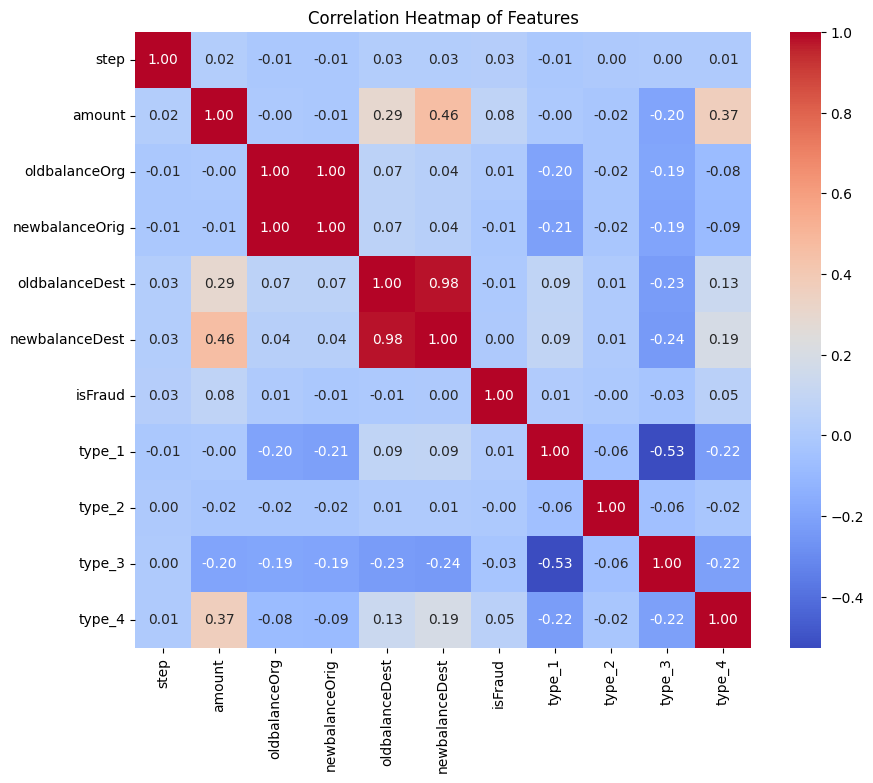

In [ ]:

df_encoded = pd.get_dummies(payment_fraud_df, columns=['type'], drop_first=True)
corr_matrix = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Features")
plt.show()

"oldbalanceOrg" and "newbalanceOrig" these two attributes are in perfect correlation (1.00). This indicates these two values are identical. </br>
Similarly, "oldbalanceDest" and "newbalanceDest" also possess almost perfect correlation (0.98), indicating they are almost the same.

In [ ]:
# removing the dependencies by dropping one of the columns from each pair
payment_fraud_df = payment_fraud_df.drop(columns=["newbalanceOrig", "newbalanceDest"])

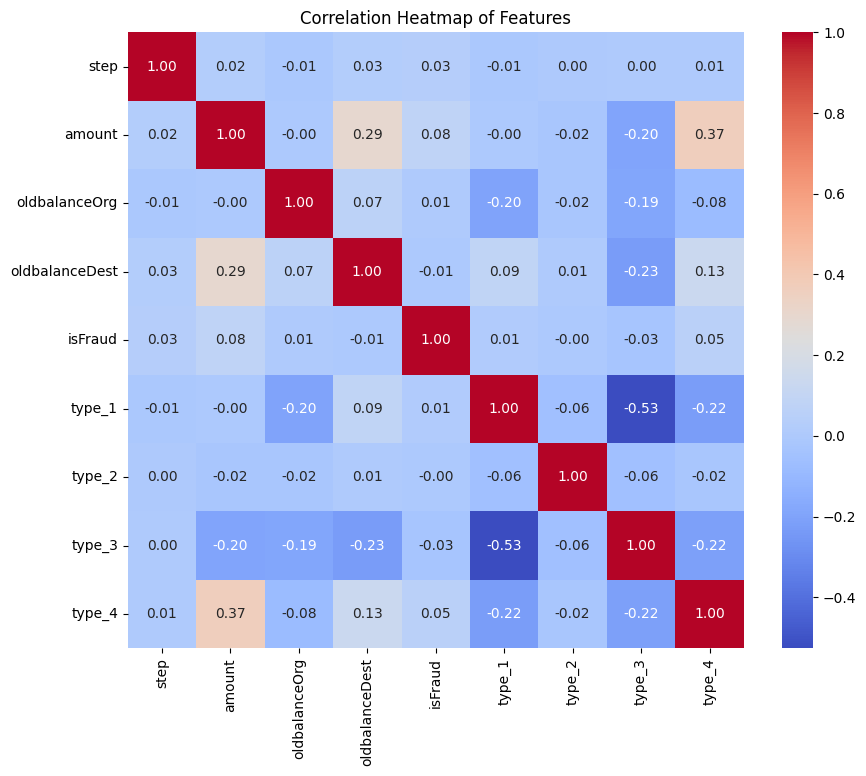

In [ ]:
df_encoded = pd.get_dummies(payment_fraud_df, columns=['type'], drop_first=True)
corr_matrix = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:

output_feature = 'isFraud'
payment_fraud_df[output_feature].value_counts()


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
output_count_list = payment_fraud_df[output_feature].value_counts().tolist()

total_outputs = payment_fraud_df.shape[0]

labels = ["Not Fraud", "Fraud"]
percentage = []

for value in output_count_list:
    percentage.append((value/total_outputs)*100)

print(f"Percentage: {percentage}")

Percentage: [99.87091795518198, 0.12908204481801522]


Not fraud: 99.87%
Fraud: 0.13%


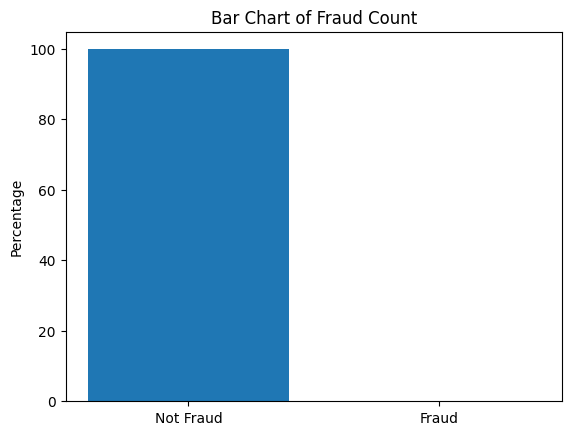

In [ ]:
barChart_labels = ["Not Fraud", "Fraud"]
notFraud, isFraud = payment_fraud_df[output_feature].value_counts().tolist()

plt.bar(barChart_labels, percentage)
plt.ylabel("Percentage")
plt.title('Bar Chart of Fraud Count')


print(f"Not fraud: {round(percentage[0], 2)}%")
print(f"Fraud: {round(percentage[1], 2)}%")

There is a massive class imbalance in the dataset. This biases machine learning models towards the majority class. 
The model becomes good at predicting the majority class but bad at the minority one.</br> Overall accuracy can be misleadingly high. 
Detection of the rare, valuable class becomes difficult. Fixing this imbalance is crucial for a helpful model. The model will be biased towards 'not fraud' results.

**<h3>Scaling<h3>**

In [ ]:

robust_scaler = RobustScaler()

In [ ]:
features = payment_fraud_df.drop(columns=['isFraud'])
target = payment_fraud_df['isFraud']


X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size=0.3, random_state=1)

In [ ]:
robust_scaler.fit(X_train)

robust_scaled_X_train = robust_scaler.transform(X_train)

In [ ]:
robust_scaler.fit(X_test)

robust_scaled_X_test = robust_scaler.transform(X_test)

In [ ]:
print("Per feature minimum before scaling")
print(X_train.min(axis=0))

Per feature minimum before scaling
step              1.0
type              0.0
amount            0.0
oldbalanceOrg     0.0
oldbalanceDest    0.0
dtype: float64


In [ ]:
# robust scaling
print("Per feature minimum after robust scaling")
print(robust_scaled_X_train.min(axis=0))

Per feature minimum after robust scaling
[-1.32960894 -0.5        -0.38294715 -0.13279552 -0.14073877]


In [ ]:
print("Per feature maximum before scaling")
X_train.max(axis=0)

Per feature maximum before scaling


step              7.430000e+02
type              4.000000e+00
amount            9.244552e+07
oldbalanceOrg     5.958504e+07
oldbalanceDest    3.560159e+08
dtype: float64

In [ ]:
print("Per feature minimum after robust scaling")
print(robust_scaled_X_train.max(axis=0))

Per feature minimum after robust scaling
[  2.81564246   1.5        472.86666688 555.56821049 377.75894427]


In [ ]:
X_train

,step,type,amount,oldbalanceOrg,oldbalanceDest
6144590,545,0,171231.46,457.00,54999.62
3201282,249,3,2858.25,0.00,0.00
4110413,302,0,116720.40,5761211.23,524292.67
5179672,359,1,260323.97,110.00,3092811.53
4187011,305,1,66806.24,0.00,267095.59
...,...,...,...,...,...
5030793,354,1,156973.09,257335.00,6697137.26
491263,19,1,140745.33,0.00,1880641.65
3937352,286,1,128095.40,0.00,8557281.75
4686059,331,3,5504.70,0.00,0.00


In [ ]:
robust_scaled_X_train

array([[ 1.70949721, -0.5       ,  0.49362561, -0.12853346, -0.0823584 ],
       [ 0.05586592,  1.        , -0.36831512, -0.13279552, -0.14073877],
       [ 0.35195531, -0.5       ,  0.21457111, 53.5973162 ,  0.41578143],
       ...,
       [ 0.26256983,  0.        ,  0.27280232, -0.13279552,  8.942547  ],
       [ 0.51396648,  1.        , -0.35476734, -0.13279552, -0.14073877],
       [ 0.38547486,  1.        , -0.17136242, -0.11206342, -0.14073877]],
      shape=(4453834, 5))

In [ ]:
os.makedirs("models", exist_ok=True)

**<h1>Logistic Regression</h1>**

In [ ]:
if os.path.exists("models/logistic_regression.joblib"):
    logistic_regression_classifier = joblib.load("models/logistic_regression.joblib")
else:
    logistic_regression_classifier = LogisticRegression(max_iter=5000)
    logistic_regression_classifier.fit(robust_scaled_X_train, Y_train)
    joblib.dump(logistic_regression_classifier, "models/logreg.joblib")

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
Y_predicted_logistic = logistic_regression_classifier.predict(robust_scaled_X_test)

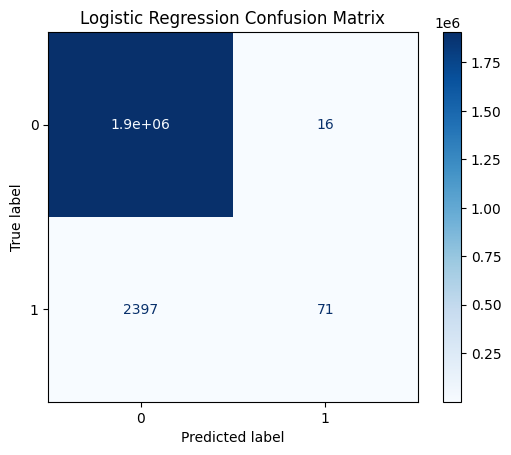

Logistic Regression model results:
Accuracy:  99.87%
Precision:  81.61%
Recall:  2.88%
F1 Score:  5.56%


In [ ]:

# Logistic Regression confusion matrix
cm_logistic = confusion_matrix(Y_test, Y_predicted_logistic)
ConfusionMatrixDisplay(cm_logistic).plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print("Logistic Regression model results:")
print(f"Accuracy:  {round(accuracy_score(Y_test, Y_predicted_logistic)*100 , 2)}%")
print(f"Precision:  {round(precision_score(Y_test, Y_predicted_logistic)*100 , 2)}%")
print(f"Recall:  {round(recall_score(Y_test, Y_predicted_logistic)*100 , 2)}%")
print(f"F1 Score:  {round(f1_score(Y_test, Y_predicted_logistic)*100 , 2)}%")

**<h1>Decision Tree</h1>**
decision tree does not require scaled data

In [ ]:
if os.path.exists("models/decision_tree.joblib"):
    tree_classifier = joblib.load("models/decision_tree.joblib")
else:
    tree_classifier = DecisionTreeClassifier(random_state=1)
    tree_classifier.fit(X_train, Y_train)
    joblib.dump(tree_classifier, "models/decision_tree.joblib")


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
Y_predicted_tree = tree_classifier.predict(X_test)

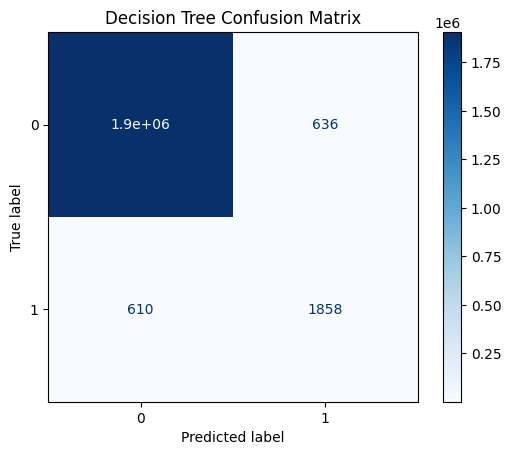

Decision tree model results:
Accuracy:  99.93%
Precision:  74.5%
Recall:  75.28%
F1 Score:  74.89%


In [ ]:
# Decision tree confusion matrix and results

cm_tree = confusion_matrix(Y_test, Y_predicted_tree)
ConfusionMatrixDisplay(cm_tree).plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

print("Decision tree model results:")
print(f"Accuracy:  {round(accuracy_score(Y_test, Y_predicted_tree)*100 , 2)}%")
print(f"Precision:  {round(precision_score(Y_test, Y_predicted_tree)*100 , 2)}%")
print(f"Recall:  {round(recall_score(Y_test, Y_predicted_tree)*100 , 2)}%")
print(f"F1 Score:  {round(f1_score(Y_test, Y_predicted_tree)*100 , 2)}%")

**<h1>Neural network</h1>**

In [ ]:
#scaled

if os.path.exists("models/nn.joblib"):
    NN_model = joblib.load("models/nn.joblib")
else:
    NN_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=300, random_state=42)
    NN_model.fit(robust_scaled_X_train, Y_train)
    joblib.dump(NN_model, "models/nn.joblib")
    
joblib.dump(robust_scaler, "models/scaler.joblib")

,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [ ]:
Y_predicted_NN = NN_model.predict(robust_scaled_X_test)

print(f"Robust scaled Neural Network Accuracy: {round(accuracy_score(Y_test, Y_predicted_NN)*100, 2)}%")

Robust scaled Neural Network Accuracy: 99.95%


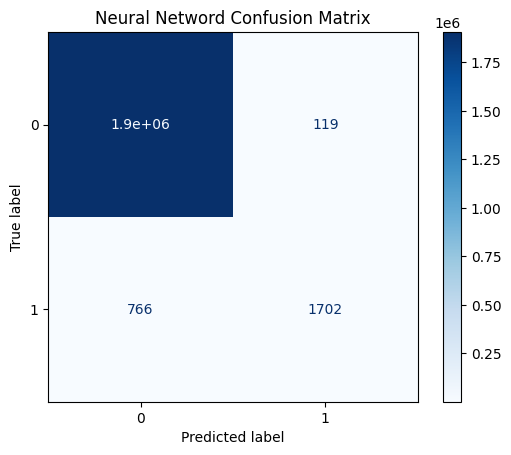

Neural Netword results
Accuracy:  99.95%
Precision:  93.47%
Recall:  68.96%
F1 Score:  79.37%


In [ ]:
cm_NN = confusion_matrix(Y_test, Y_predicted_NN)
ConfusionMatrixDisplay(cm_NN).plot(cmap="Blues")
plt.title("Neural Netword Confusion Matrix")
plt.show()

print(f"Neural Netword results")
print(f"Accuracy:  {round(accuracy_score(Y_test, Y_predicted_NN)*100 , 2)}%")
print(f"Precision:  {round(precision_score(Y_test, Y_predicted_NN)*100 , 2)}%")
print(f"Recall:  {round(recall_score(Y_test, Y_predicted_NN)*100 , 2)}%")
print(f"F1 Score:  {round(f1_score(Y_test, Y_predicted_NN)*100 , 2)}%")

**<h1>ROC & AUC</h1>**

In [ ]:
supervised_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Neural Network": MLPClassifier()
}

In [ ]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "legend.fontsize": 13,
})

plt.figure(figsize=(12, 6))

for model_name, model_classifier in supervised_models.items():
    model_classifier.fit(robust_scaled_X_train, Y_train)

    Y_probability_predict = model_classifier.predict_proba(robust_scaled_X_test)[:, 1]

    false_positive_rate, true_positive_rate, _ = roc_curve(Y_test, Y_probability_predict)
    roc_auc = auc(false_positive_rate, true_positive_rate)

    plt.plot(false_positive_rate, true_positive_rate, linewidth=2.2, label=f"{model_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", frameon=False)
plt.grid(alpha=0.25)

plt.savefig("fraud-roc.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

In [ ]:
print(roc_auc)

0.9973515979414781


Text(0.5, 1.0, 'Prediction Accuracy of Classification Models')

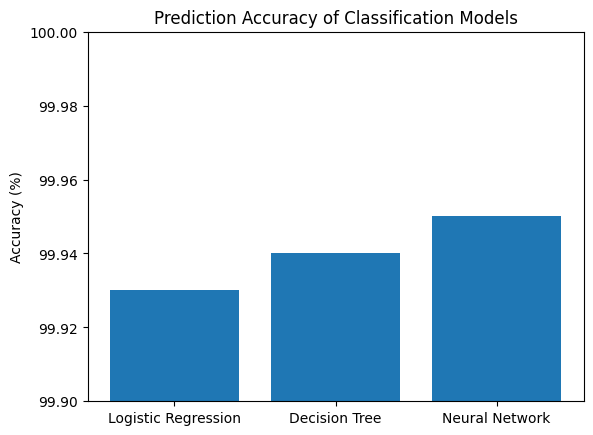

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Neural Network']
accuracies = [99.93, 99.94, 99.95]

bars = plt.bar(models, accuracies)
plt.ylim(99.90, 100.00)
plt.ylabel('Accuracy (%)')
plt.title('Prediction Accuracy of Classification Models')

In [ ]:
print("Logistic Regression:")
print(classification_report(Y_test, Y_predicted_logistic))

print("Decision Tree")
print(classification_report(Y_test, Y_predicted_tree))

print("Neural Network")
print(classification_report(Y_test, Y_predicted_NN))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906318
           1       0.82      0.03      0.06      2468

    accuracy                           1.00   1908786
   macro avg       0.91      0.51      0.53   1908786
weighted avg       1.00      1.00      1.00   1908786

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906318
           1       0.74      0.75      0.75      2468

    accuracy                           1.00   1908786
   macro avg       0.87      0.88      0.87   1908786
weighted avg       1.00      1.00      1.00   1908786

Neural Network
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906318
           1       0.93      0.69      0.79      2468

    accuracy                           1.00   1908786
   macro avg       0.97      0.84      0.90   1908786
weighted avg       1.00 